# Lab 04 — 5G broadcast ISD and numerology

Compare CP-limited SFN feasibility with typical ISD for HPHT/MPMT topologies.

,Numerology (SCS),Cyclic Prefix (µs),Coverage (%),Observed ISD (km)
0,0.37kHz,300.0,9.02,43.2
1,1.25kHz,200.0,3.46,43.2
2,2.5kHz,100.0,0.00,43.2


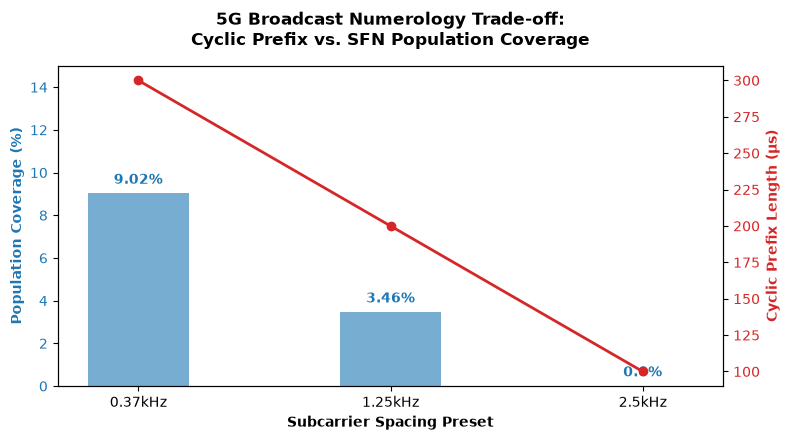

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import matplotlib.pyplot as plt
from broadcast_planner.core.regions import DEFAULT_REGION, EXAMPLES_DIR
from broadcast_planner.core.grids import read_raster, make_grid
from broadcast_planner.core.sites import load_sites
from broadcast_planner.fiveg_bc.models import FiveGBroadcastConfig, NUMEROLOGY_PRESETS
from broadcast_planner.fiveg_bc.coverage import run_fiveg_broadcast_coverage

# Load layers using the verified 250m resolution
dem, _ = read_raster(DEFAULT_REGION.dem_path())
clutter, _ = read_raster(DEFAULT_REGION.clutter_path())
population, _ = read_raster(DEFAULT_REGION.population_path())
grid = make_grid(DEFAULT_REGION, resolution_m=250.0)
sites = load_sites(EXAMPLES_DIR / 'sites.yaml')

# Gather results into a list of dictionaries
records = []
for numerology in NUMEROLOGY_PRESETS:
    cfg = FiveGBroadcastConfig(numerology=numerology)
    res = run_fiveg_broadcast_coverage(sites, grid, dem, clutter, population, cfg)
    
    records.append({
        "Numerology (SCS)": numerology,
        "Cyclic Prefix (µs)": cfg.max_sfn_delay_us,
        "Coverage (%)": res.population_stats['coverage_percent'],
        "Observed ISD (km)": round(res.isd_km_observed, 1)
    })

# 1. Display rich structured table
df = pd.DataFrame(records)
display(df)

# 2. Plot the engineering relationship
fig, ax1 = plt.subplots(figsize=(8, 4.5))

color = '#1f77b4'
ax1.set_xlabel('Subcarrier Spacing Preset', fontweight='bold')
ax1.set_ylabel('Population Coverage (%)', color=color, fontweight='bold')
bars = ax1.bar(df["Numerology (SCS)"], df["Coverage (%)"], color=color, alpha=0.6, width=0.4, label='Coverage %')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(0, 15)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2.0, yval + 0.3, f"{yval}%", ha='center', va='bottom', color=color, fontweight='bold')

ax2 = ax1.twinx()  
color = '#d62728'
ax2.set_ylabel('Cyclic Prefix Length (µs)', color=color, fontweight='bold')
line = ax2.plot(df["Numerology (SCS)"], df["Cyclic Prefix (µs)"], color=color, marker='o', linewidth=2, label='CP (µs)')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('5G Broadcast Numerology Trade-off:\nCyclic Prefix vs. SFN Population Coverage', fontsize=12, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()